In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
early_twenties = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/100simulation_results_age_20_24.csv')
late_twenties = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/100simulation_results_age_25_29.csv')
early_thirties = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/100simulation_results_age_30_34.csv')

In [12]:
# define wanted window
df = early_twenties

In [13]:
stable_95 = df[~df['first_sample_size_95'].isnull()]['roi'].tolist()
stable_99 = df[~df['first_sample_size_99'].isnull()]['roi'].tolist()

print(f"rois that stabilized for 95% CI: {stable_95}")
print(f"rois that stabilized for 99% CI: {stable_99}")

# save the list of 95% stable rois to load to step10

import json

# Load from the same directory
with open("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/stable_95_early_twenties.json", "w") as f: #CHANGE ACCORDING TO AGE BIN
    json.dump(stable_95, f)
print(f"Saved {len(stable_95)} ROIs to JSON.")# Example: print(roi_list_95[:5])

rois that stabilized for 95% CI: [32, 33, 35, 40, 65, 92, 98, 99, 100, 102, 103, 104, 105, 107, 108, 113, 114, 143, 152, 155, 169, 193, 198, 231, 233, 234, 235, 237, 239, 240, 241, 242, 243, 256, 268, 269, 270, 293, 302, 303, 304, 305, 306, 308, 309, 311, 312, 318, 323, 340, 360, 370, 391, 414, 416, 418, 421, 422, 423, 428, 441, 442, 443, 448, 449]
rois that stabilized for 99% CI: [33, 35, 65, 92, 98, 99, 100, 102, 103, 104, 143, 152, 169, 193, 233, 234, 235, 237, 239, 240, 241, 242, 243, 268, 270, 302, 303, 304, 305, 306, 308, 309, 311, 318, 360, 414, 416, 418, 421, 422, 423, 443, 448]
Saved 65 ROIs to JSON.


In [ ]:
# pie chart of null vs non-null for 95% and 99% CI stabilization
stable_95_count = df['first_sample_size_95'].notnull().sum()
unstable_95_count = df['first_sample_size_95'].isnull().sum()
stable_99_count = df['first_sample_size_99'].notnull().sum()
unstable_99_count = df['first_sample_size_99'].isnull().sum()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.pie([stable_95_count, unstable_95_count], labels=['Stable', 'Unstable'], autopct='%1.1f%%', colors=['mediumseagreen', 'lightcoral'])
plt.title('95% CI Stabilization')
plt.subplot(1, 2, 2)
plt.pie([stable_99_count, unstable_99_count], labels=['Stable', 'Unstable'], autopct='%1.1f%%', colors=['mediumseagreen', 'lightcoral'])
plt.title('99% CI Stabilization')
plt.tight_layout()
plt.show()

minimal sample size for 99% CI: 70.0
minimal sample size for 95% CI: 33.0


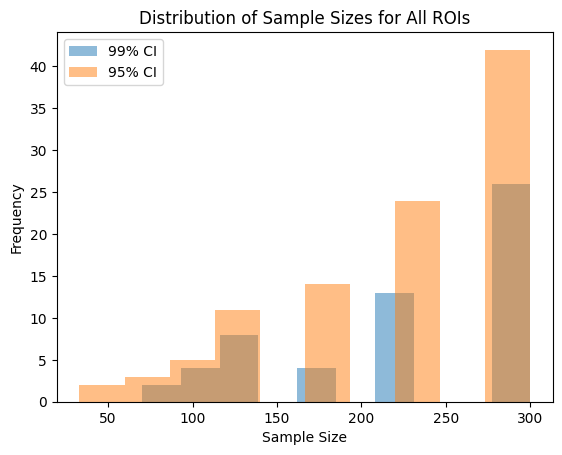

In [5]:
print(f"minimal sample size for 99% CI: {df['first_sample_size_99'].min()}")
print(f"minimal sample size for 95% CI: {df['first_sample_size_95'].min()}")

# plot a histogram of first_sample_size_99 and first_sample_size_95 for all rois
plt.hist(df['first_sample_size_99'], alpha=0.5, label='99% CI')
plt.hist(df['first_sample_size_95'], alpha=0.5, label='95% CI')
plt.xlabel('Sample Size')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Sizes for All ROIs')
plt.legend()
plt.show()